In [45]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [46]:
src = ['../data/my_typing_data.csv']

# Load the data

In [47]:
tables = [pd.read_csv(file) for file in src]
table = pd.concat(tables)

delays_sample = table['delay'].to_numpy()
transitions_sample = table['transition'].to_numpy()
categories = {0: 'letter', 1: 'space', 2: 'enter', 3: 'punctuation'}

table.info()

count = len(categories)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   delay       364 non-null    int64 
 1   transition  364 non-null    object
dtypes: int64(1), object(1)
memory usage: 5.8+ KB


# Visualization utilities

In [48]:
def transition_code(state1, state2):
    return str(state1) + "-" + str(state2)


def from_transition_code(code: str):
    splitted = code.split('-')
    return int(splitted[0]), int(splitted[1])


def transition_label(state1, state2):
    return str(categories[state1]) + '->' + str(categories[state2])


expected_transitions = []

for i in range(count**2):
    expected_transitions.append(
        transition_code(
            np.mod(
                i,
                len(categories)),
            i //
            len(categories)))

# Computation utilities

In [49]:
def group(values: np.ndarray, categories: np.ndarray, expected_categories):
    unique_categories = np.unique(categories)
    groupped = {}
    for category in expected_categories:
        groupped[category] = np.array([])
    for category in unique_categories:
        groupped[category] = values[categories == category]
    return groupped


def compute_cdf(data: dict[str, np.ndarray]):
    cdfs = {}
    for category in data.keys():
        distribution = data[category]
        values, freq = np.unique(distribution, return_counts=True)
        order = values.argsort()
        values, freq = values[order], freq[order]
        cdf = freq.cumsum().astype(np.float64)
        cdf /= freq.sum()

        if (len(cdf) == 0):
            cdf = np.array([1])
            values = np.array([0])

        cdfs[category] = {'values': values, 'cdf': cdf}

    return cdfs

Small math interlude:

Let $F$ be a distribution function. That means
1. $F$ is monotonously increasing
2. $F$ is right continuous
3. $\lim_{x\to -\infty} F(x) = 0$
4. $\lim_{x\to \infty} F(x) = 1$

$$X: [0,1] \to \mathbb{R}, t \mapsto \inf\{x:F(x) \geq t\}$$

We notice the following:
$$\inf\{x:F(x) \geq t\} \leq a \Leftrightarrow F(a) \geq t$$

The backward direction is trivial so we only check the forward one:

Let $M = \inf\{x:F(x) \geq t\} \leq a$. Then for all $\delta > 0$ we can find such $x$ in a feasible set that $x - M < \delta$. Pick $\varepsilon = F(a) - F(M)$, which is non-negative by monotonicity of $F$. Right continuity of $F$ ensures, that there exists $\delta > 0$, s.t. $F(y) - F(M) < \varepsilon$ for all $M \leq y < M + \delta$. In particular it holds that $F(x) - F(M) < \varepsilon = F(a) - F(M)$, so $F(a) > F(x) \geq t$

We hence conclude that $X^{-1}((-\infty;a]) = [0;F(a)]$, so the mapping $X$ is $[0;1]\doublecap \mathcal{B}_1 \to \mathcal{B}_1$ measurable, since the preimage under $X$ of the generating set of $\mathcal{B}_1$ lies in $[0;1]\doublecap \mathcal{B}_1$

Also we have that $\lambda(X^{-1}((-\infty;a])) = F(a)$, so the push-forward measure induced by $X$ has the distribution $F$

We have that the probability measure induced by the uniform distribution on a unit interval is exactly Lebesgue measure restricted to $[0;1]$. We define $Y(\omega) = \inf\{x:F(x) \geq U(\omega)\}$, and observe the following:

$$Y(\omega)\leq a \Leftrightarrow U(\omega) \leq F(a)$$

Therefore:
$$\mathbb{P}(Y \leq a) = \mathbb{P}(U(\omega) \leq F(a)) = F(a)$$
and $\mathbb{P}_Y \sim F$



In [50]:
def model_rv(t, distribution):
    indices = np.searchsorted(distribution['cdf'], t, side='right') - 1
    return distribution['values'][indices]

What we did is basically computed the condtional distribution of $X$, represnting the time between two key presses. Formally:
$$X_{ij} \sim \mathbb{P}(X \mid \text{prev key} = i, \text{current key} = j)$$

Plots in the section [Visualization](#visualization) suggest that we can use exponential distribution to model the process of typing. Below we estimate the parameter using the principle of maximum likelihood:

$$f(x) = \lambda e^{-\lambda x}$$

$$\max_{\lambda \in (0;\infty)} \prod_{i=1}^{n} f(x_i) 
= \max_{\lambda \in (0;\infty)} \prod_{i=1}^{n} \lambda e^{-\lambda x_i} 
= \max_{\lambda \in (0;\infty)} \lambda^n e^{-\lambda \sum_{i=1}^{n} x_i}$$

Since logarithm is a monotonous function, it doesn't change the location of maximum:
$$\ln \left(\lambda^n e^{-\lambda \sum_{i=1}^{n} x_i}\right) 
= n\ln(\lambda) - \lambda \sum_{i=1}^{n} x_i$$

Since the set $(0;\infty)$ is open, we can write the first order necessary condition:
$$\partial_{\lambda} \left(n\ln(\lambda) - \lambda \sum_{i=1}^{n} x_i\right)
= \frac{n}{\lambda} - \sum_{i=1}^{n} x_i = 0 \Leftrightarrow
\lambda = \frac{n}{\sum_{i=1}^{n} x_i}$$

The second order sufficient condition:
$$\partial^2_{\lambda} \left(n\ln(\lambda) - \lambda \sum_{i=1}^{n} x_i\right)
= -\frac{n}{\lambda^2} < 0 \; \forall \lambda \in (0, \infty)$$

That means the values for $\lambda$ found above is indeed optimal. It is also important to verify whether all $x_i$ are positive

<a id='visualization'></a>
# Visualization

## Compute the distributions

In [51]:
data = group(delays_sample, transitions_sample, expected_transitions)
distribution = compute_cdf(data)

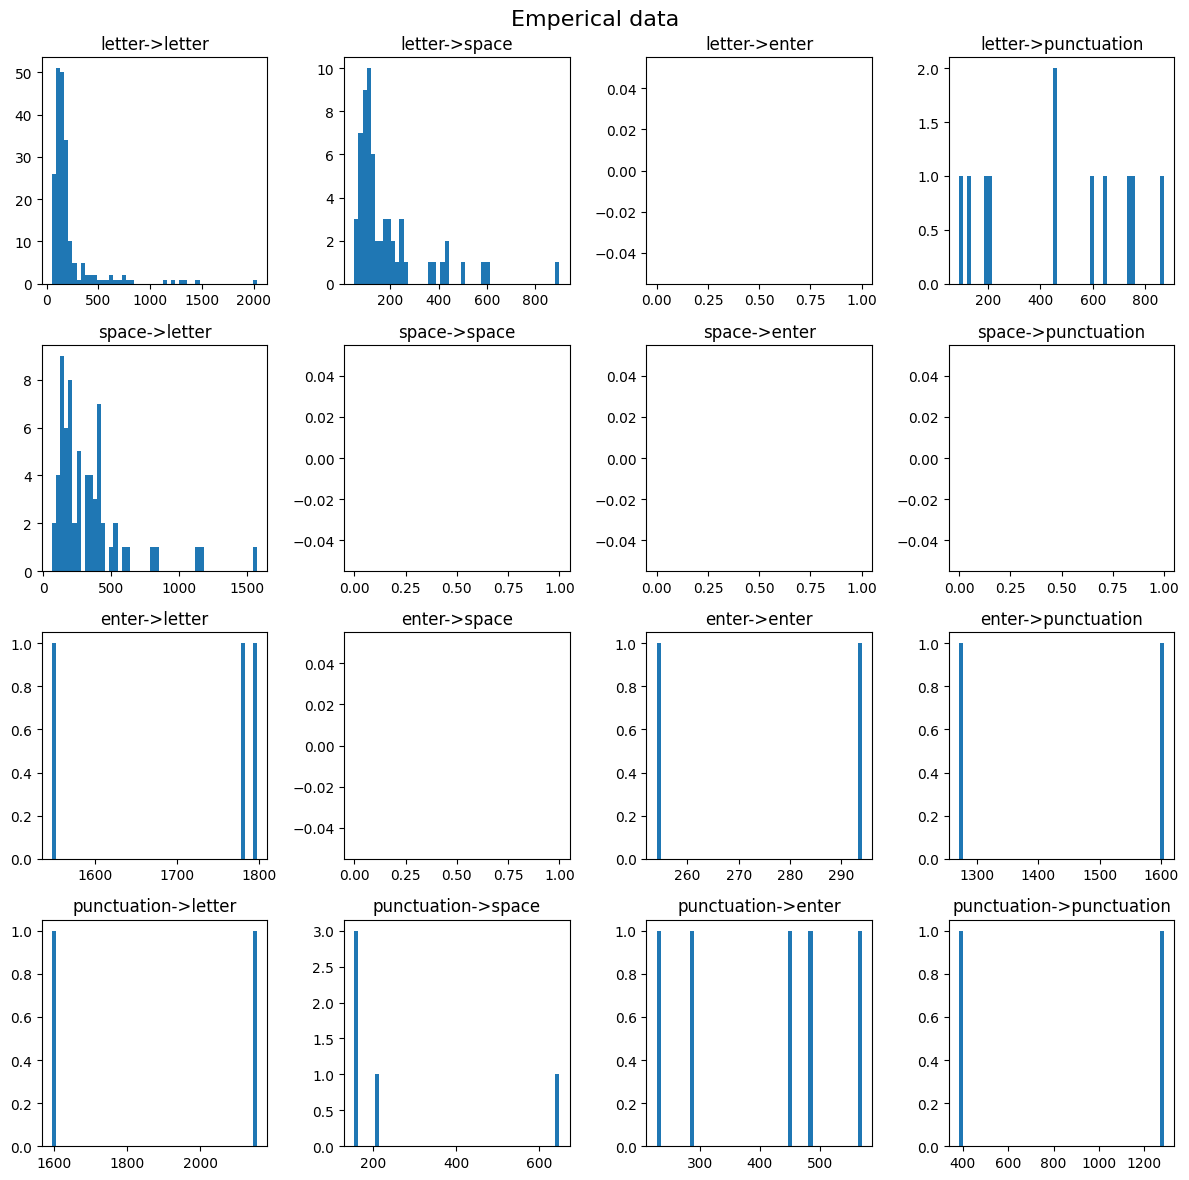

In [52]:
fig, axes = plt.subplots(count, count, figsize=(12, 12))

for code in expected_transitions:
    i, j = from_transition_code(code)
    axes[i, j].set_title(transition_label(i, j))
    axes[i, j].hist(data[code], bins=50)

fig.suptitle('Emperical data', fontsize=16)
plt.tight_layout()
plt.show()

lambda = 0.0045103518074409805


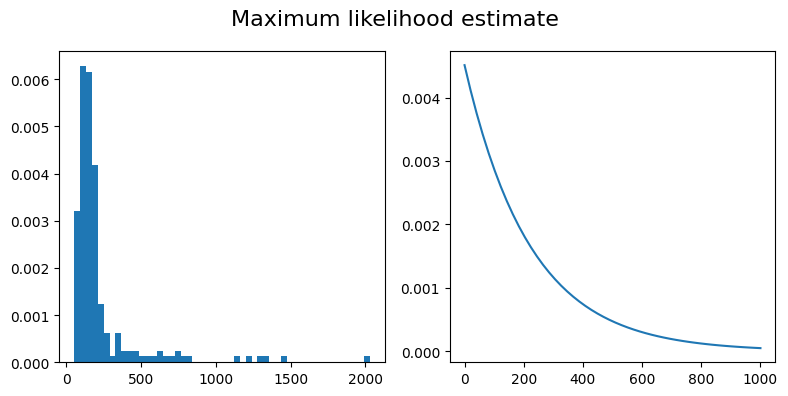

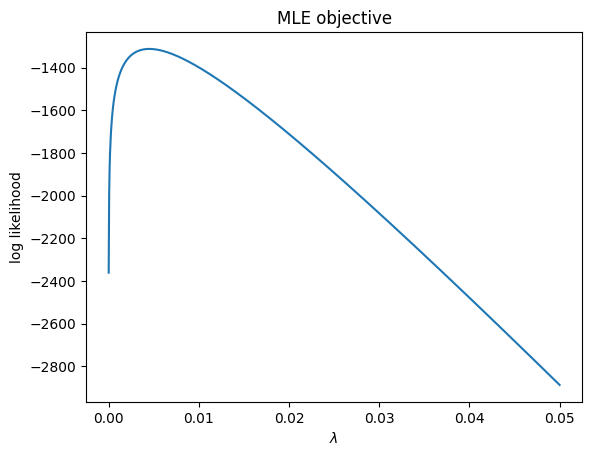

In [53]:
target = '0-0'
n = len(data[target])
l = 1.0 / np.mean(data[target])
x = np.linspace(0, 1000)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].hist(data[target], bins=50, density=True)

axes[1].plot(x, l * np.exp(-l * x))

print("lambda =", l)

fig.suptitle('Maximum likelihood estimate', fontsize=16)
plt.tight_layout()
plt.show()

plt.title('MLE objective')
plt.xlabel('$\\lambda$')
plt.ylabel('log likelihood')
l_values = np.linspace(0.00001, 0.05, 1000)
plt.plot(l_values, n * np.log(l_values) - l_values * np.sum(data[target]))
plt.show()

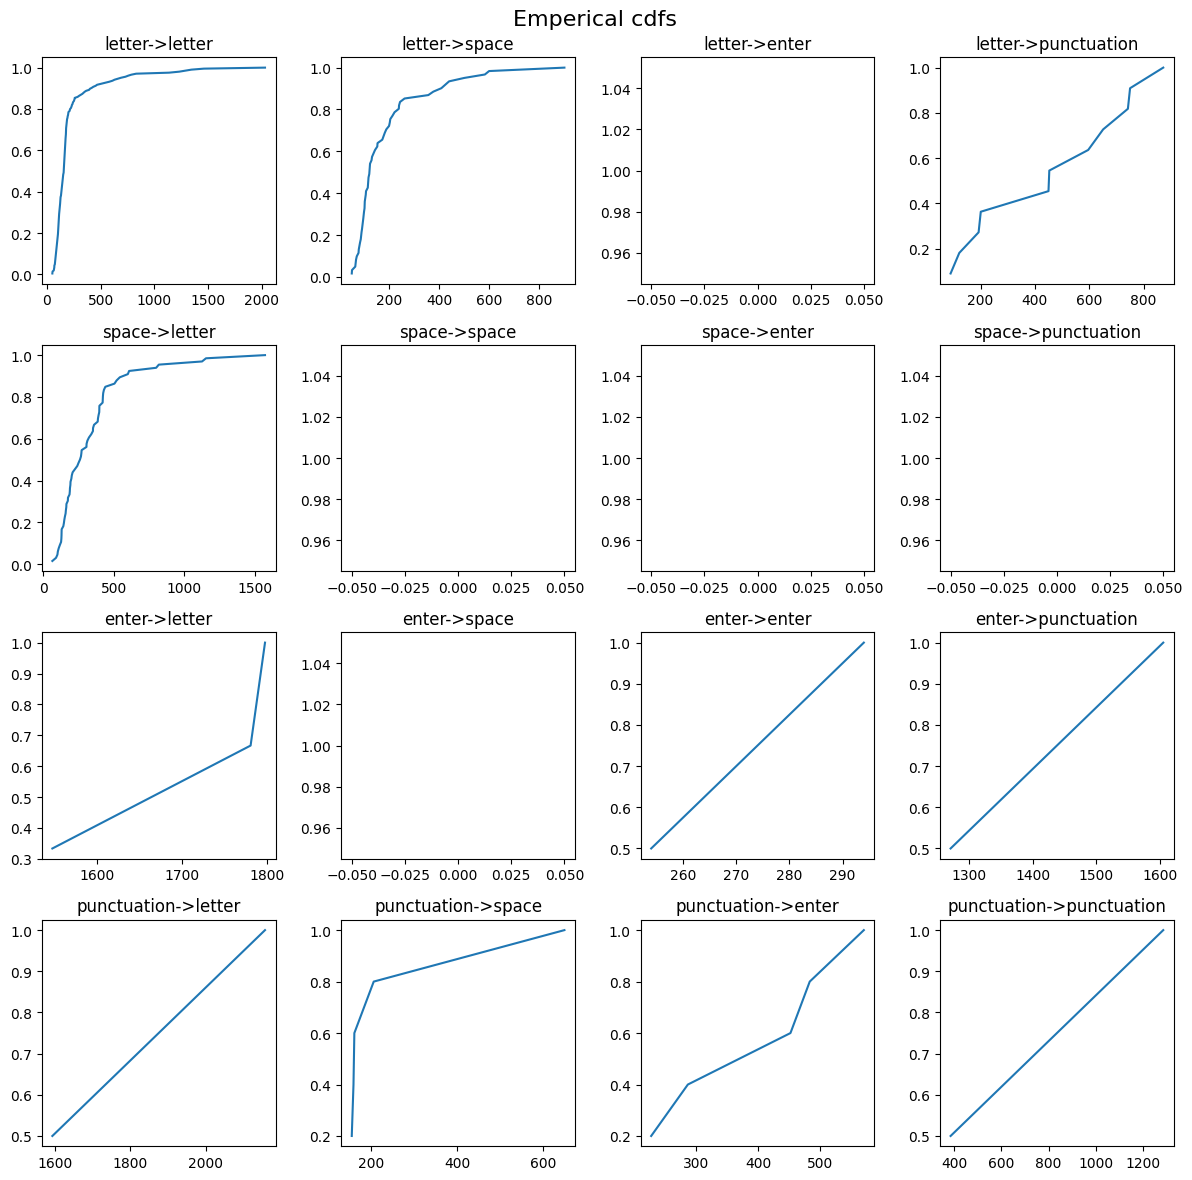

In [54]:
fig, axes = plt.subplots(count, count, figsize=(12, 12))

for code in expected_transitions:
    i, j = from_transition_code(code)
    axes[i, j].set_title(transition_label(i, j))
    axes[i, j].plot(distribution[code]['values'], distribution[code]['cdf'])

fig.suptitle('Emperical cdfs', fontsize=16)
plt.tight_layout()
plt.show()

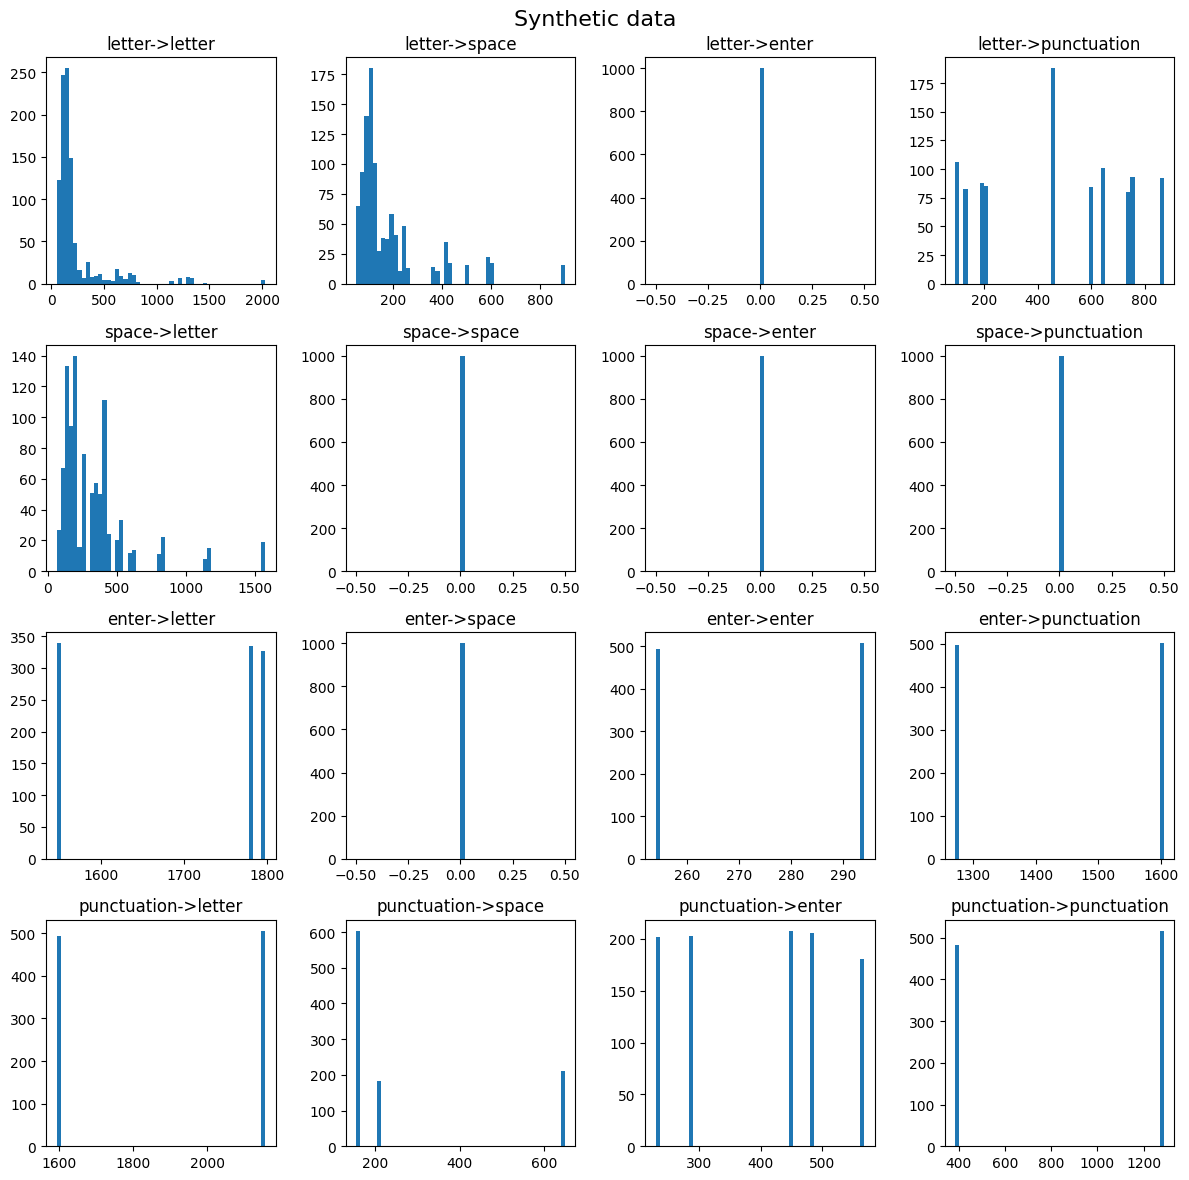

In [55]:
fig, axes = plt.subplots(count, count, figsize=(12, 12))
n = 1000

for code in expected_transitions:
    i, j = from_transition_code(code)
    t = np.random.rand(n)
    values = model_rv(t, distribution[code])

    axes[i, j].set_title(transition_label(i, j))
    axes[i, j].hist(values, bins=50)

fig.suptitle('Synthetic data', fontsize=16)
plt.tight_layout()
plt.show()

In [59]:
import time
import sys
import re

text = "привет! привет? пока!!!!. двоеточие:: "


def get_token(char):
    if re.search(r"[а-яА-ЯёЁa-zA-Z0-9]", char):
        return 0
    elif char == ' ':
        return 1
    elif char == '\n':
        return 2
    elif char in ['.', ',', '-', ':', ';', '?', '!', '@', '#', '$', '%', '^', '&', '*', '(', ')', '"']:
        return 3
    else:
        raise ValueError('unknown token type')


def type_text(text, delay=0.1):
    speed_factor = 1.5
    for ind in range(len(text)):
        sys.stdout.write(text[ind])
        sys.stdout.flush()

        if ind < len(text) - 1:
            t = np.random.rand()
            code = transition_code(
                get_token(text[ind]), get_token(text[ind + 1]))
            delay = model_rv(t, distribution[code])
            time.sleep(delay / 1000 / speed_factor)


type_text(text)

привет! привет? пока!!!!. двоеточие:: 

# Export into json format

In [57]:
import json

cdf_export = {}

for code in expected_transitions:
    cdf_export[code] = {
        "time_values": distribution[code]['values'].tolist(),
        "cdf_values": distribution[code]['cdf'].tolist()
    }

js_content = "const distributions = " + json.dumps(
    cdf_export,
    indent=2,
    ensure_ascii=False
) + ";"

with open("../data/typing_cdfs.js", "w", encoding="utf-8") as f:
    f.write(js_content)